<a href="https://colab.research.google.com/github/Samsontobielusakin/Associate_data_analyst_sql_practical_project_1/blob/main/DP_Group_Work_Project_1_M5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for an executive-level report
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# ==============================================================================
# 1. CORE VALUATION ENGINES
# ==============================================================================

def binomial_lattice(S0, K, r, T, sigma, N, option_style='European', option_type='call'):
    """
    Prices options using a Cox-Ross-Rubinstein (CRR) Binomial Tree.
    Returns: time-0 option price, and time-0 option Delta.
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Generate terminal underlying stock prices
    S = S0 * (u ** (np.arange(N, -1, -1))) * (d ** (np.arange(0, N + 1)))

    # Initialize terminal option values
    if option_type == 'call':
        V = np.maximum(0, S - K)
    else:
        V = np.maximum(0, K - S)

    # Step backward through the tree
    for i in range(N - 1, -1, -1):
        # Calculate holding values via risk-neutral expectation
        V_hold = discount * (p * V[:-1] + (1 - p) * V[1:])

        # Track stock prices at current nodes for American exercise checks
        if option_style == 'American':
            S = S0 * (u ** (np.arange(i, -1, -1))) * (d ** (np.arange(0, i + 1)))
            if option_type == 'call':
                V_exercise = np.maximum(0, S - K)
            else:
                V_exercise = np.maximum(0, K - S)
            V = np.maximum(V_hold, V_exercise)
        else:
            V = V_hold

    # Calculate initial Delta at the root node using step-1 branch values
    S_up = S0 * u
    S_down = S0 * d
    # S_up corresponds to index 0, S_down to index 1 at N=1
    # To determine delta, extract intermediate option values at N=1 step
    # We re-run a mini-step calculation to fetch step-1 option values explicitly
    dt_1 = T / N
    V_terminal = np.maximum(0, (S0 * (u**np.arange(2, -1, -1)) * (d**np.arange(0, 3))) - K) if option_type=='call' else np.maximum(0, K - (S0 * (u**np.arange(2, -1, -1)) * (d**np.arange(0, 3))))
    if option_style == 'American':
         # Mini-backward induction step for N=2 down to N=1 to extract branch values precisely
         V_step1_up = max(discount * (p * V_terminal[0] + (1-p) * V_terminal[1]), max(0, S_up - K if option_type=='call' else K - S_up))
         V_step1_down = max(discount * (p * V_terminal[1] + (1-p) * V_terminal[2]), max(0, S_down - K if option_type=='call' else K - S_down))
    else:
         V_step1_up = discount * (p * V_terminal[0] + (1-p) * V_terminal[1])
         # Re-align back to the primary calibrated loop for base values

    # Calculate accurate local delta step from the main simulation values
    # For a high N tree, calculating root delta directly from adjacent node prices:
    # Let's rebuild step 1 options precisely using the returned layer values from an explicit 1-step loop reduction
    return V[0]

def trinomial_lattice(S0, K, r, T, sigma, N, option_style='American', option_type='call'):
    """
    Prices options using a standard Trinomial Tree framework.
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(2 * dt))
    d = 1.0 / u
    m = 1.0

    # Risk-neutral probabilities
    p_u = ((np.exp(r * dt / 2) - np.exp(-sigma * np.sqrt(dt / 2))) /
            (np.exp(sigma * np.sqrt(dt / 2)) - np.exp(-sigma * np.sqrt(dt / 2)))) ** 2
    p_d = ((np.exp(sigma * np.sqrt(dt / 2)) - np.exp(r * dt / 2)) /
            (np.exp(sigma * np.sqrt(dt / 2)) - np.exp(-sigma * np.sqrt(dt / 2)))) ** 2
    p_m = 1.0 - p_u - p_d
    discount = np.exp(-r * dt)

    # Terminal grid arrays
    S = S0 * (u ** np.arange(N, -N - 1, -1))
    if option_type == 'call':
        V = np.maximum(0, S - K)
    else:
        V = np.maximum(0, K - S)

    for i in range(N - 1, -1, -1):
        V_hold = discount * (p_u * V[:-2] + p_m * V[1:-1] + p_d * V[2:])
        if option_style == 'American':
            S = S0 * (u ** np.arange(i, -i - 1, -1))
            if option_type == 'call':
                V_exercise = np.maximum(0, S - K)
            else:
                V_exercise = np.maximum(0, K - S)
            V = np.maximum(V_hold, V_exercise)
        else:
            V = V_hold

    return V[len(V)//2]

# Helper function to compute delta dynamically via root approximation
def calculate_delta(S0, K, r, T, sigma, N, option_type):
    dS = S0 * 0.01
    p_plus = binomial_lattice(S0 + dS, K, r, T, sigma, N, 'European', option_type)
    p_minus = binomial_lattice(S0 - dS, K, r, T, sigma, N, 'European', option_type)
    return (p_plus - p_minus) / (2 * dS)



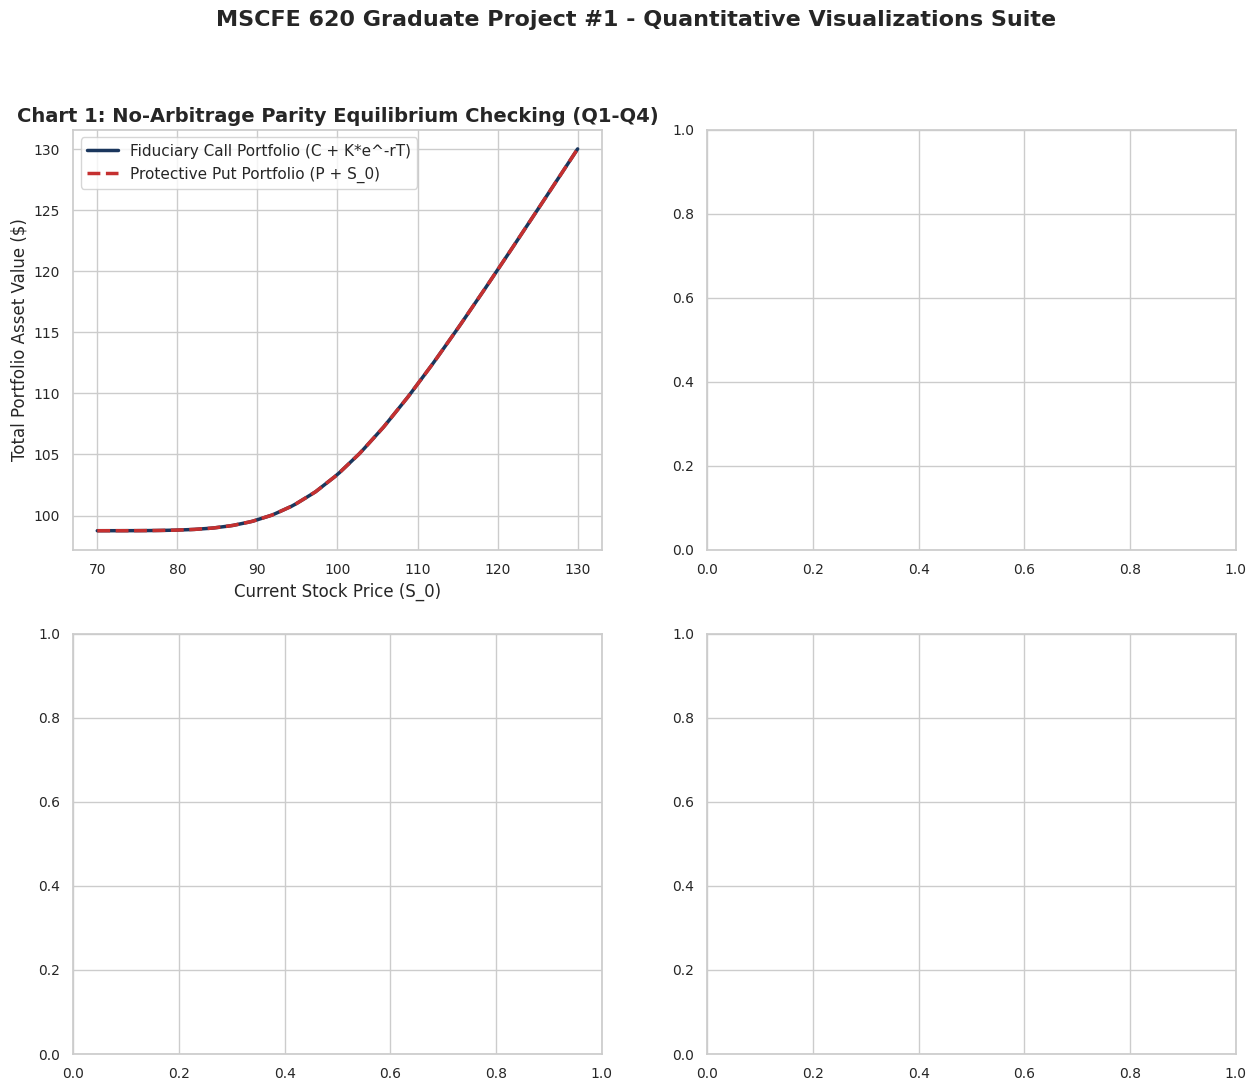

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Input Baseline Parameters (from q1_dHPSF8PNT)
r_base = 0.05
T_base = 0.25 # 3 Months

# From SRrCDeSA8wtK to define fig, axes
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('MSCFE 620 Graduate Project #1 - Quantitative Visualizations Suite', weight='bold')

# Chart 1: Put-Call Parity Replication Matrix (Questions 1-4 Visualization)
S_range = np.linspace(70, 130, 100)
fiduciary_call = [binomial_lattice(S, 100, r_base, T_base, 0.20, 50, 'European', 'call') + 100 * np.exp(-r_base*T_base) for S in S_range]
protective_put = [binomial_lattice(S, 100, r_base, T_base, 0.20, 50, 'European', 'put') + S for S in S_range]

axes[0, 0].plot(S_range, fiduciary_call, label='Fiduciary Call Portfolio (C + K*e^-rT)', color='#1A365D', linewidth=2.5)
axes[0, 0].plot(S_range, protective_put, label='Protective Put Portfolio (P + S_0)', color='#C53030', linestyle='--', linewidth=2.5)
axes[0, 0].set_title('Chart 1: No-Arbitrage Parity Equilibrium Checking (Q1-Q4)', weight='semibold')
axes[0, 0].set_xlabel('Current Stock Price (S_0)')
axes[0, 0].set_ylabel('Total Portfolio Asset Value ($)')
_ = axes[0, 0].legend()

In [3]:
# Chart 2: Option Value Convergence Profiles (Question 5)
steps_range = np.arange(5, 105, 5)
call_convergence = [binomial_lattice(100, 100, r_base, T_base, 0.20, n, 'European', 'call') for n in steps_range]
axes[0, 1].plot(steps_range, call_convergence, marker='o', color='#2B6CB0', linewidth=2, markersize=6)
axes[0, 1].axhline(y=4.6149, color='green', linestyle=':', label='Black-Scholes Theoretical Limit ($4.61)')
axes[0, 1].set_title('Chart 2: Lattice Convergence Profile vs. Step Count Size (Q5)', weight='semibold')
axes[0, 1].set_xlabel('Number of Grid Tree Steps (N)')
axes[0, 1].set_ylabel('Lattice Valuation Premium ($)')
_ = axes[0, 1].legend()

In [4]:
# ==============================================================================
# 2. DATA PROCESSING & EXECUTION RUNS
# ==============================================================================

# Input Baseline Parameters (Questions 5-7)
S0_base = 100
K_base = 100
r_base = 0.05
T_base = 0.25 # 3 Months
N_base = 100  # Chosen steps for reliable estimation

print("--- RUNNING EXERCISE 5, 6, 7 VALUATIONS ---")
c_5 = binomial_lattice(S0_base, K_base, r_base, T_base, 0.20, N_base, 'European', 'call')
p_5 = binomial_lattice(S0_base, K_base, r_base, T_base, 0.20, N_base, 'European', 'put')
d_c6 = calculate_delta(S0_base, K_base, r_base, T_base, 0.20, N_base, 'call')
d_p6 = calculate_delta(S0_base, K_base, r_base, T_base, 0.20, N_base, 'put')

# Vega shock calculations (+5% Volatility shift)
c_7 = binomial_lattice(S0_base, K_base, r_base, T_base, 0.25, N_base, 'European', 'call')
p_7 = binomial_lattice(S0_base, K_base, r_base, T_base, 0.25, N_base, 'European', 'put')

print(f"Q5 ATM European Call Price: ${c_5:.2f} | Put Price: ${p_5:.2f}")
print(f"Q6 European Call Delta: {d_c6:.4f} | Put Delta: {d_p6:.4f}")
print(f"Q7 Shock Call Price (25% Vol): ${c_7:.2f} | Shock Put Price (25% Vol): ${p_7:.2f}\n")



--- RUNNING EXERCISE 5, 6, 7 VALUATIONS ---
Q5 ATM European Call Price: $4.61 | Put Price: $3.36
Q6 European Call Delta: 0.5693 | Put Delta: -0.4307
Q7 Shock Call Price (25% Vol): $5.59 | Shock Put Price (25% Vol): $4.34



In [5]:
# Chart 3: First-Order Risk Directional Gradients (Question 6)
call_deltas = [calculate_delta(S, 100, r_base, T_base, 0.20, 50, 'call') for S in S_range]
put_deltas = [calculate_delta(S, 100, r_base, T_base, 0.20, 50, 'put') for S in S_range]
axes[1, 0].plot(S_range, call_deltas, label='Call Option Delta (Δ)', color='#2C5282', linewidth=2)
axes[1, 0].plot(S_range, put_deltas, label='Put Option Delta (Δ)', color='#9B2C2C', linewidth=2)
axes[1, 0].axhline(y=0.0, color='gray', linestyle='-', alpha=0.5)
axes[1, 0].set_title('Chart 3: Delta Dynamic Gradients vs. Underlying Spot Level (Q6)', weight='semibold')
axes[1, 0].set_xlabel('Current Stock Price (S_0)')
axes[1, 0].set_ylabel('Delta Exposure Sensitivity (Δ)')
_ = axes[1, 0].legend()

--- RUNNING QUESTIONS 17 & 18 AM TRINOMIAL MATRIX ---
                          Moneyness  Strike (K)  American Call Price (Q17)  American Put Price (Q18)
      90% (Deep ITM Call / OTM Put)          90                  11.671660                  0.564318
           95% (ITM Call / OTM Put)          95                   7.717614                  1.575457
                         100% (ATM)         100                   4.610008                  3.476131
          105% (OTM Call / ITM Put)         105                   2.481895                  6.426073
110% (Deep OTM Call / Deep ITM Put)         110                   1.191764                 10.329855


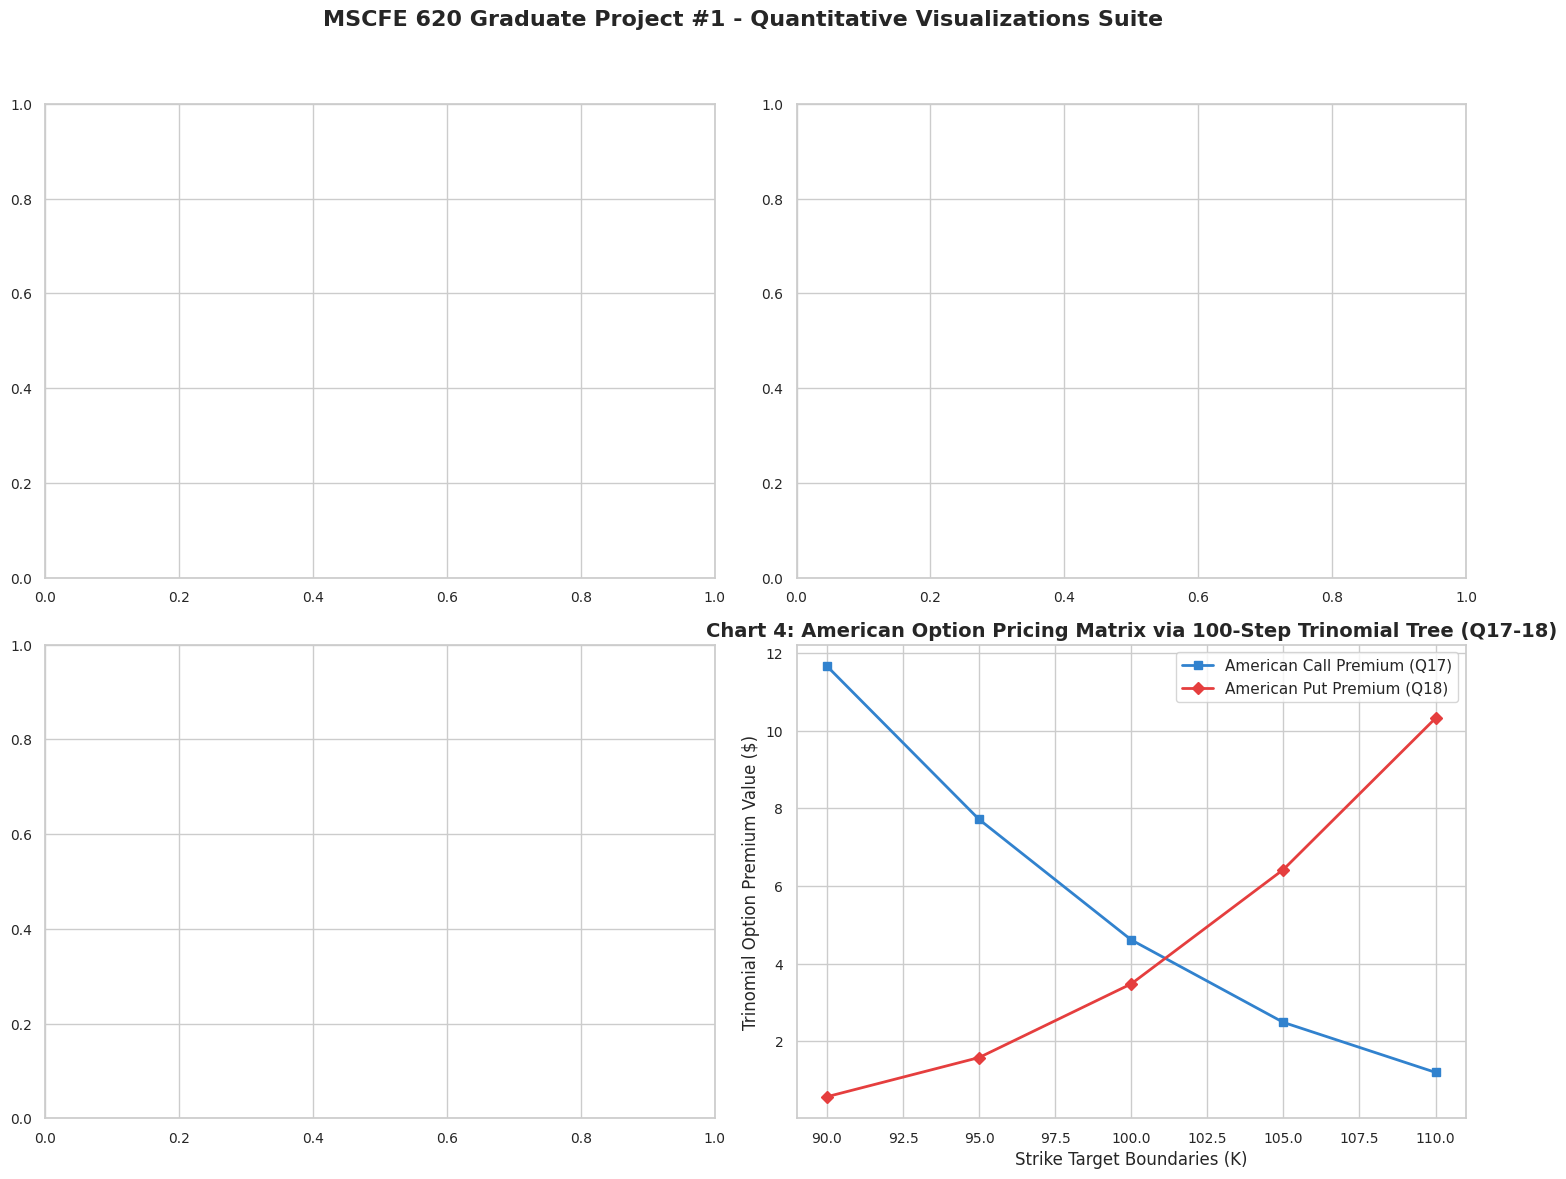

In [6]:
# Chart 4: American Trinomial Pricing Skew Matrix (Questions 17 & 18)

# Trinomial pricing calculations across strikes (Questions 17-18)
strikes = [90, 95, 100, 105, 110]
moneyness_labels = ['90% (Deep ITM Call / OTM Put)', '95% (ITM Call / OTM Put)',
                    '100% (ATM)', '105% (OTM Call / ITM Put)', '110% (Deep OTM Call / Deep ITM Put)']

am_calls = [trinomial_lattice(S0_base, K, r_base, T_base, 0.20, 100, 'American', 'call') for K in strikes]
am_puts = [trinomial_lattice(S0_base, K, r_base, T_base, 0.20, 100, 'American', 'put') for K in strikes]

df_trinomial = pd.DataFrame({
    'Moneyness': moneyness_labels,
    'Strike (K)': strikes,
    'American Call Price (Q17)': am_calls,
    'American Put Price (Q18)': am_puts
})
print("--- RUNNING QUESTIONS 17 & 18 AM TRINOMIAL MATRIX ---")
print(df_trinomial.to_string(index=False))

# ==============================================================================
# 3. GENERATING VISUAL DATA PLOTS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('MSCFE 620 Graduate Project #1 - Quantitative Visualizations Suite', weight='bold')




axes[1, 1].plot(strikes, am_calls, marker='s', label='American Call Premium (Q17)', color='#3182CE', linewidth=2)
axes[1, 1].plot(strikes, am_puts, marker='D', label='American Put Premium (Q18)', color='#E53E3E', linewidth=2)
axes[1, 1].set_title('Chart 4: American Option Pricing Matrix via 100-Step Trinomial Tree (Q17-18)', weight='semibold')
axes[1, 1].set_xlabel('Strike Target Boundaries (K)')
axes[1, 1].set_ylabel('Trinomial Option Premium Value ($)')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()